In [ ]:
import seaborn as sns

penguins = sns.load_dataset("penguins")
print(penguins.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [ ]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
penguins.isnull().sum() #결측치가 많음->종별 평균 대치

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [ ]:
####성별 결측치 처리
#penguins.dropna(subset=["sex"])
penguins["sex"] = penguins["sex"].fillna("Unknown") #제3의 카테고리 만들기

In [ ]:
#날개길이, 부리 길이, 부리 너비, 몸무게 결측치 2개씩
# penguins["body_mass_g"] = penguins["body_mass_g"].fillna() #평균대체-> 몸무게마다 종이 다를수 있어 좋은 방법은 아님
penguins["body_mass_g"] = penguins["body_mass_g"].fillna(penguins.groupby("species")["body_mass_g"].transform("mean")) #종별 평균 대체
penguins["bill_length_mm"] = penguins["bill_length_mm"].fillna(penguins.groupby("species")["bill_length_mm"].transform("mean"))
penguins["bill_depth_mm"] = penguins["bill_depth_mm"].fillna(penguins.groupby("species")["bill_depth_mm"].transform("mean"))
penguins["flipper_length_mm"] = penguins["flipper_length_mm"].fillna(penguins.groupby("species")["flipper_length_mm"].transform("mean"))
#범주형 -> 최빈값 대체로 많이 함

In [ ]:
penguins.info() #null이 다 대치가 됨

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     344 non-null    float64
 3   bill_depth_mm      344 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                344 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

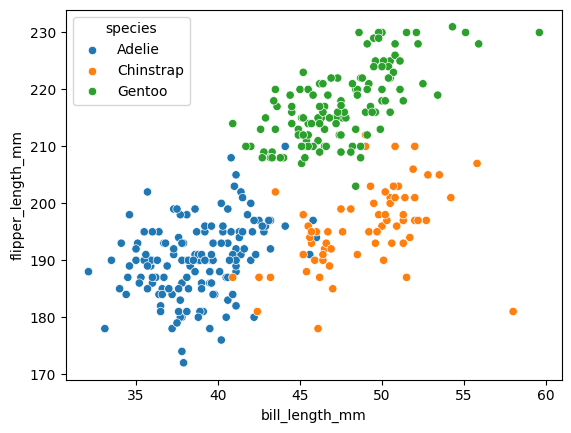

In [ ]:
sns.scatterplot(data=penguins,
                x="bill_length_mm",
                y="flipper_length_mm",
                hue="species") #종에 따라 다른 색을 찍어라, 지정하지 않으면 전부 검정색, 레이블마다 다른 색 찍기

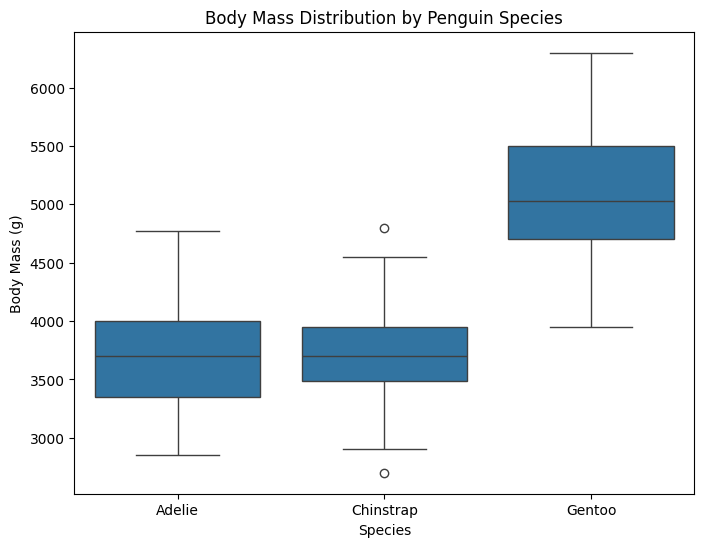

In [ ]:
import matplotlib.pyplot as plt

# 그래프 그리기
plt.figure(figsize=(8, 6))
sns.boxplot(data=penguins, x="species", y="body_mass_g")

plt.title("Body Mass Distribution by Penguin Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.show()

/tmp/ipykernel_262/1633948657.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


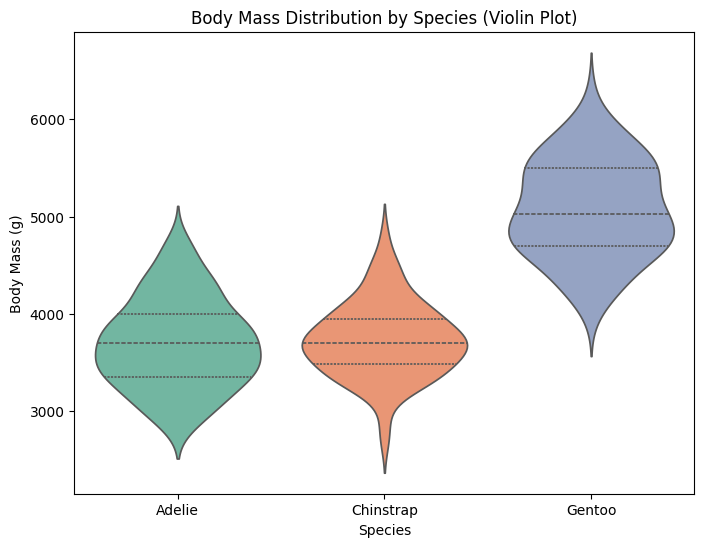

In [ ]:
# 바이올린 플롯: 데이터들이 어떻게 분포되어있는지도 보여줌
plt.figure(figsize=(8,6))
sns.violinplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    inner="quartile",   # 중앙값 + 사분위 표시
    palette="Set2"
)

plt.title("Body Mass Distribution by Species (Violin Plot)")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")

plt.show()

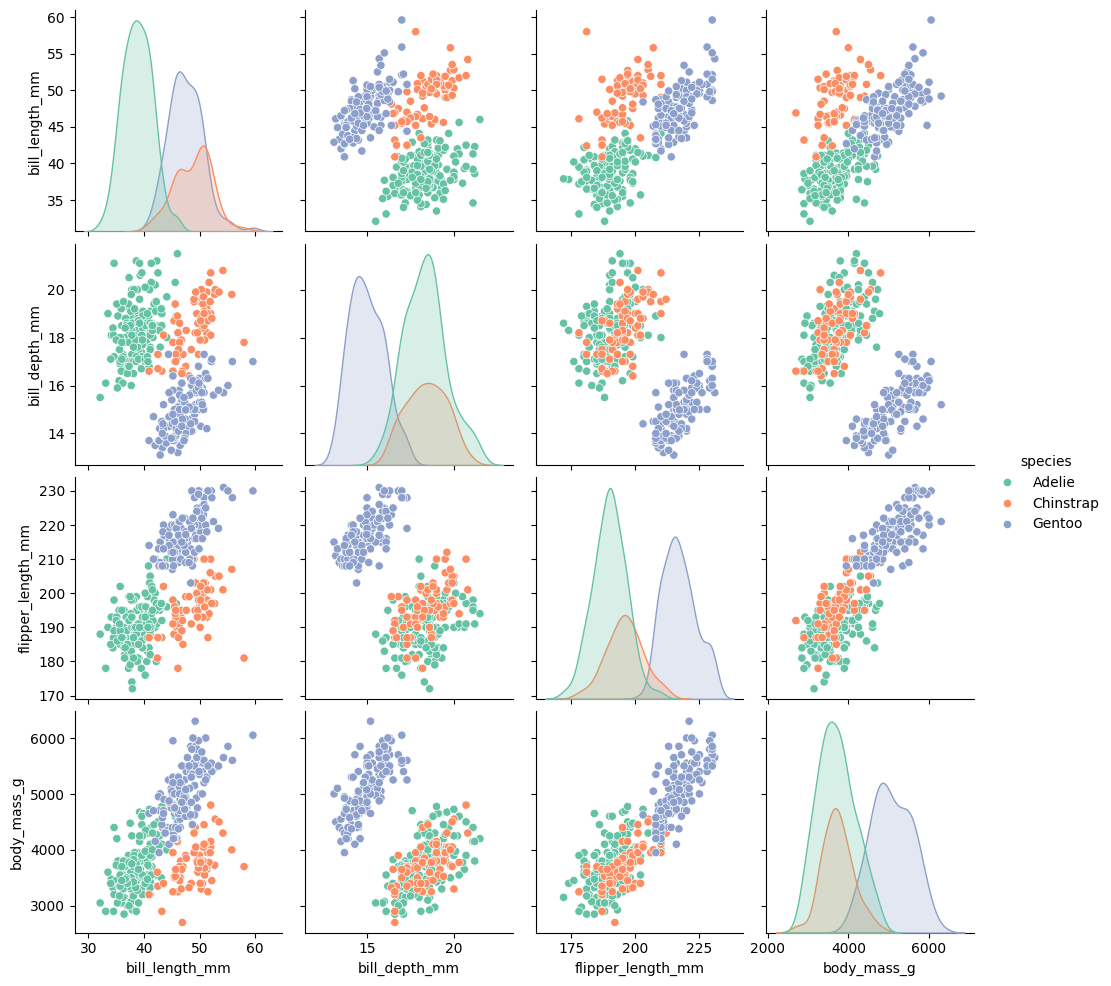

In [ ]:
# pairplot
sns.pairplot(
    penguins,
    hue="species",
    diag_kind="kde",   # 대각선 분포를 부드럽게
    palette="Set2"
)

plt.show()
#변수 선택

In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 데이터 불러오기
penguins = sns.load_dataset("penguins")

# 필요한 변수만 선택하고 결측치 제거
data = penguins[["bill_length_mm", "flipper_length_mm", "species"]].dropna() #null 제거

# 입력(X), 정답(y)
X = data[["bill_length_mm", "flipper_length_mm"]] #전진 선택법
y = data["species"]

# 학습용 / 테스트용 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SVM 모델 생성 및 학습
model = SVC(kernel="linear")
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 결과 출력
print("정확도:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

정확도: 0.9855072463768116

              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



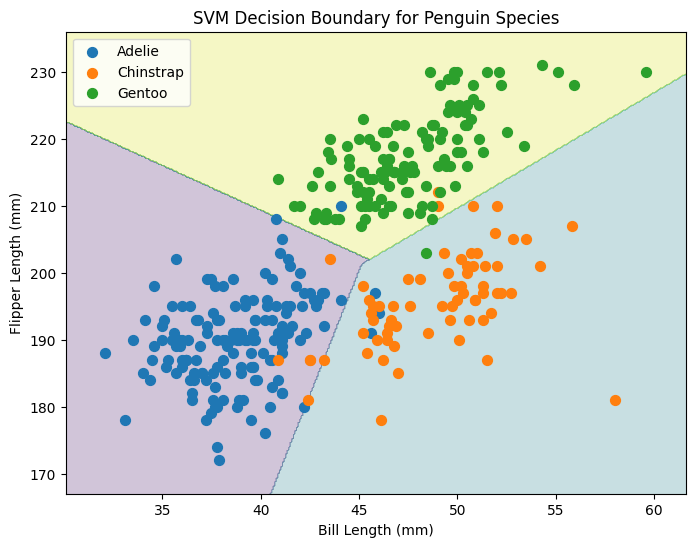

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# 데이터 불러오기
penguins = sns.load_dataset("penguins")

# 필요한 열만 사용
data = penguins[["bill_length_mm", "flipper_length_mm", "species"]].dropna()

X = data[["bill_length_mm", "flipper_length_mm"]].values
y = data["species"].values

# 문자열 라벨을 숫자로 변환
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# SVM 학습
model = SVC(kernel="linear")
model.fit(X, y_encoded)

# 격자 생성
x_min, x_max = X[:, 0].min() - 2, X[:, 0].max() + 2
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

# 예측
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 배경 영역
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25)

# 실제 점
for i, species in enumerate(le.classes_):
    plt.scatter(
        X[y_encoded == i, 0],
        X[y_encoded == i, 1],
        label=species,
        s=50
    )

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("SVM Decision Boundary for Penguin Species")
plt.legend()
plt.show()

In [ ]:
new_penguin = [[46.0, 210.0]]  # bill_length_mm, flipper_length_mm
pred = model.predict(new_penguin)

# LabelEncoder 사용한 버전이면
print("예측 종:", le.inverse_transform(pred)[0])

예측 종: Gentoo


In [ ]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 데이터 불러오기
penguins = sns.load_dataset("penguins")

# 필요한 변수 선택
data = penguins[[
    "bill_length_mm",
    "flipper_length_mm",
    "species"
]].dropna()

X = data[["bill_length_mm", "flipper_length_mm"]]
y = data["species"]

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 생성 및 학습
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 정확도
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9710144927536232


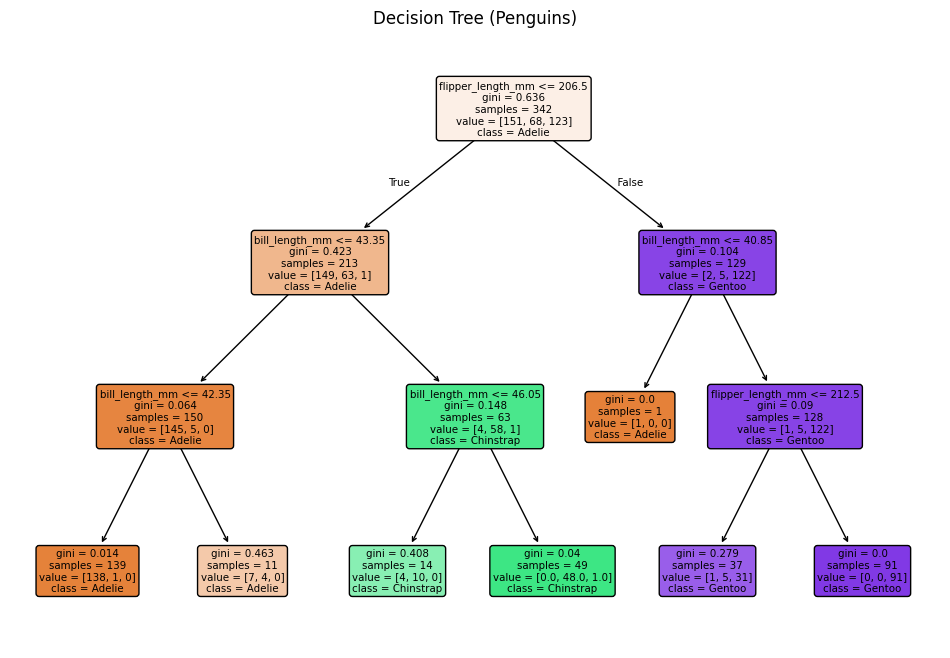

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 데이터
penguins = sns.load_dataset("penguins")
data = penguins[[
    "bill_length_mm",
    "flipper_length_mm",
    "species"
]].dropna()

X = data[["bill_length_mm", "flipper_length_mm"]]
y = data["species"]

# 모델 학습
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)

# 트리 시각화
plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=["bill_length_mm", "flipper_length_mm"],
    class_names=model.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree (Penguins)")
plt.show()